In [1]:
# GloVe Embeddings Loading and Vector Representation

In [5]:
import numpy as np

## Download GloVe Embeddings

We will download the pre-trained GloVe embeddings (specifically `glove.6B.zip` containing 100-dimensional vectors trained on 6 Billion tokens from Wikipedia and Gigaword datasets). This file is about 822MB, so the download may take a few minutes.

In [4]:
import os

# Create a directory to store the GloVe embeddings
if not os.path.exists('glove.6B'):
    os.makedirs('glove.6B')

# Download the GloVe embeddings if not already present
if not os.path.exists('glove.6B/glove.6B.100d.txt'):
    print("Downloading GloVe embeddings...")
    !wget -nc http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -o glove.6B.zip -d glove.6B
    print("GloVe embeddings downloaded and extracted.")
else:
    print("GloVe embeddings already present.")

GloVe embeddings already present.


## Loading GloVe Embeddings into a Dictionary

Now, we'll load the downloaded GloVe embeddings (specifically the 100-dimensional vectors) into a Python dictionary. The dictionary will map each word to its corresponding numerical vector representation.

In [6]:
embeddings_index = {}
# Specify the path to the 100-dimensional GloVe file
glove_file_path = 'glove.6B/glove.6B.100d.txt'

print(f"Loading GloVe embeddings from {glove_file_path}...")
with open(glove_file_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Loading GloVe embeddings from glove.6B/glove.6B.100d.txt...
Found 400000 word vectors.


Before running the previous cell, ensure that `numpy` is imported, as it's used for `np.asarray`.

In [7]:
# Example: Look up the vector for a word
word = "hello"
if word in embeddings_index:
    word_vector = embeddings_index[word]
    print(f"Vector for '{word}':")
    print(word_vector)
    print(f"Vector dimension: {len(word_vector)}")
else:
    print(f"'{word}' not found in GloVe embeddings.")

Vector for 'hello':
[ 0.26688    0.39632    0.6169    -0.77451   -0.1039     0.26697
  0.2788     0.30992    0.0054685 -0.085256   0.73602   -0.098432
  0.5479    -0.030305   0.33479    0.14094   -0.0070003  0.32569
  0.22902    0.46557   -0.19531    0.37491   -0.7139    -0.51775
  0.77039    1.0881    -0.66011   -0.16234    0.9119     0.21046
  0.047494   1.0019     1.1133     0.70094   -0.08696    0.47571
  0.1636    -0.44469    0.4469    -0.93817    0.013101   0.085964
 -0.67456    0.49662   -0.037827  -0.11038   -0.28612    0.074606
 -0.31527   -0.093774  -0.57069    0.66865    0.45307   -0.34154
 -0.7166    -0.75273    0.075212   0.57903   -0.1191    -0.11379
 -0.10026    0.71341   -1.1574    -0.74026    0.40452    0.18023
  0.21449    0.37638    0.11239   -0.53639   -0.025092   0.31886
 -0.25013   -0.63283   -0.011843   1.377      0.86013    0.20476
 -0.36815   -0.68874    0.53512   -0.46556    0.27389    0.4118
 -0.854     -0.046288   0.11304   -0.27326    0.15636   -0.20334
  0

## Cosine Similarity between Word Vectors

Cosine similarity is a metric used to measure how similar two vectors are. In the context of word embeddings, it quantifies the semantic similarity between two words. A higher cosine similarity indicates greater semantic resemblance.

In [9]:
from numpy.linalg import norm

def cosine_similarity(vec1, vec2):
    """
    Calculates the cosine similarity between two vectors.
    """
    # Ensure vectors are non-zero to avoid division by zero
    if norm(vec1) == 0 or norm(vec2) == 0:
        return 0.0 # Or handle as an error, depending on desired behavior

    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# Example usage:
word1 = "king"
word2 = "queen"

if word1 in embeddings_index and word2 in embeddings_index:
    vector1 = embeddings_index[word1]
    vector2 = embeddings_index[word2]

    similarity = cosine_similarity(vector1, vector2)
    print(f"Cosine similarity between '{word1}' and '{word2}': {similarity:.4f}")
else:
    print(f"One or both words ('{word1}', '{word2}') not found in GloVe embeddings.")

Cosine similarity between 'king' and 'queen': 0.7508


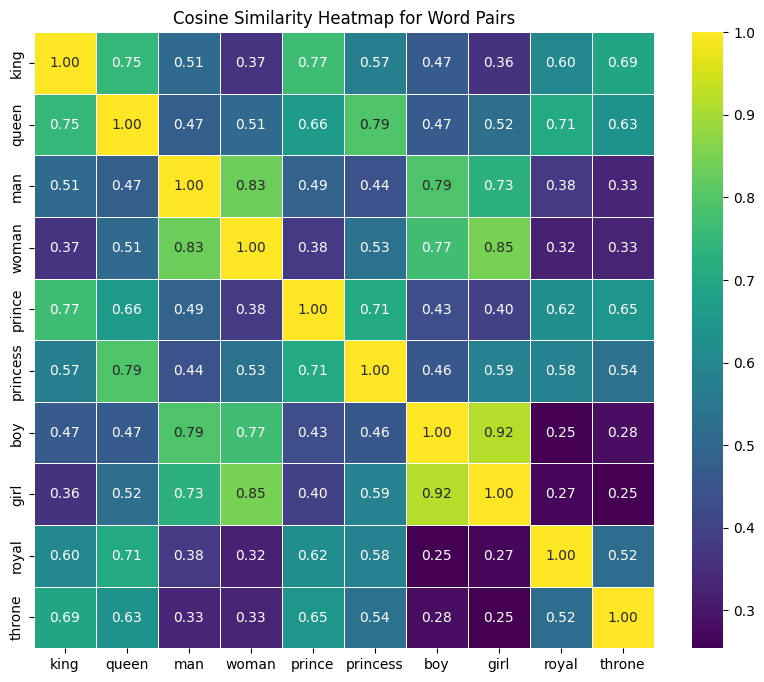

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define a list of words for which to calculate pairwise similarities
words_to_compare = ["king", "queen", "man", "woman", "prince", "princess", "boy", "girl", "royal", "throne"]

# Filter out words not found in the embeddings_index
existing_words = [word for word in words_to_compare if word in embeddings_index]
if len(existing_words) < len(words_to_compare):
    missing_words = list(set(words_to_compare) - set(existing_words))
    print(f"Warning: The following words were not found in GloVe embeddings and will be excluded: {missing_words}")

# Get vectors for the existing words
word_vectors = {word: embeddings_index[word] for word in existing_words}

# Initialize a similarity matrix
similarity_matrix = np.zeros((len(existing_words), len(existing_words)))

# Calculate pairwise cosine similarities
for i, word1 in enumerate(existing_words):
    for j, word2 in enumerate(existing_words):
        vec1 = word_vectors[word1]
        vec2 = word_vectors[word2]
        similarity_matrix[i, j] = cosine_similarity(vec1, vec2)

# Create a DataFrame for better heatmap visualization with labels
similarity_df = pd.DataFrame(similarity_matrix, index=existing_words, columns=existing_words)

# Plot the heatmap
fig = plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Cosine Similarity Heatmap for Word Pairs')
plt.show()
